In [ ]:
!pip install kagglehub

import kagglehub
from kagglehub import KaggleDatasetAdapter
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [ ]:
path = kagglehub.dataset_download("rtatman/speech-accent-archive")

file_path1 = os.path.join(path, "speakers_all.csv")
df = pd.read_csv(file_path1)

Using Colab cache for faster access to the 'speech-accent-archive' dataset.


## EDA Start
Some basic EDA to start with on the speech accent archive dataset

In [ ]:
print(df.shape)

(2172, 12)


The dataset contains 2,172 speakers and 12 columns.

In [ ]:
df.head(5)

,age,age_onset,birthplace,filename,native_language,sex,speakerid,country,file_missing?,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,24.0,12.0,"koussi, senegal",balanta,balanta,male,788,senegal,True,NaN,NaN,NaN
1,18.0,10.0,"buea, cameroon",cameroon,cameroon,male,1953,cameroon,True,NaN,NaN,NaN
2,48.0,8.0,"hong, adamawa, nigeria",fulfulde,fulfulde,male,1037,nigeria,True,NaN,NaN,NaN
3,42.0,42.0,"port-au-prince, haiti",haitian,haitian,male,1165,haiti,True,NaN,NaN,NaN
4,40.0,35.0,"port-au-prince, haiti",haitian,haitian,male,1166,haiti,True,NaN,NaN,NaN


Each row represents one speakers.
Key features are:
- age
- age_onset
- native_language
- sex
- country
- birthplace

It seems that there are 3 features that are unnecessary:
- Unnamed: 9
- Unnamed: 10
- Unnamed: 11

Let's clean it up.

In [ ]:
# Drop unnamed columns
df = df.drop(columns=[c for c in df.columns if c.startswith('Unnamed')], errors='ignore')
print(df.shape)

(2172, 9)


In [ ]:
# Summary statistics
df.describe()

,age,age_onset,speakerid
count,2172.000000,2172.000000,2172.000000
mean,33.117173,8.833333,1088.449355
std,14.453039,8.451127,628.420329
min,0.000000,0.000000,1.000000
25%,22.000000,0.000000,543.750000
50%,28.000000,8.000000,1088.500000
75%,41.000000,13.000000,1632.250000
max,97.000000,86.000000,2176.000000


This shows that the average speaker is 33 years old, and the average age of English onset is 8 years old.

In [ ]:
# Check to see what type each features are
df.dtypes

,0
age,float64
age_onset,float64
birthplace,object
filename,object
native_language,object
sex,object
speakerid,int64
country,object
file_missing?,bool


In [ ]:
# Check for missing values per column
print('Missing Values per column:')
print(df.isnull().sum())

Missing Values per column:
age                0
age_onset          0
birthplace         4
filename           0
native_language    0
sex                0
speakerid          0
country            5
file_missing?      0
dtype: int64


From this we see that of the 2172 samples, 32 of them have a file_missing column set to true, we will want to drop them as they do not have an audio file to use. We do this later below

In [ ]:
print(f"File missing: {df['file_missing?'].sum()} / {len(df)}")
print(f"\nSuspicious age=0 rows: {(df['age'] == 0).sum()}")
print(df[df['age'] == 0][['age', 'age_onset', 'native_language', 'country']].head(10))

File missing: 32 / 2172

Suspicious age=0 rows: 4
      age  age_onset native_language country
1970  0.0        0.0     synthesized     NaN
1971  0.0        0.0     synthesized     NaN
1972  0.0        0.0     synthesized     NaN
1973  0.0        0.0     synthesized     NaN


It seems that `birthplace` is missing 4 values and `country` is missing 5 values.

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2172 entries, 0 to 2171
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              2172 non-null   float64
 1   age_onset        2172 non-null   float64
 2   birthplace       2168 non-null   object 
 3   filename         2172 non-null   object 
 4   native_language  2172 non-null   object 
 5   sex              2172 non-null   object 
 6   speakerid        2172 non-null   int64  
 7   country          2167 non-null   object 
 8   file_missing?    2172 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(5)
memory usage: 138.0+ KB
None


## Data Cleaning
Let's clean the dataset by checking for missing/null values and cleaning them up by removing them.

In [ ]:
# Drop empty artifact columns
df = df.drop(columns=[c for c in df.columns if c.startswith('Unnamed')])

# Remove rows with missing audio files
df = df[df['file_missing?'] == False].copy()

print(f"Shape after cleaning: {df.shape}")
print(f"Remaining columns: {list(df.columns)}")

Shape after cleaning: (2140, 9)
Remaining columns: ['age', 'age_onset', 'birthplace', 'filename', 'native_language', 'sex', 'speakerid', 'country', 'file_missing?']


In [ ]:
# print the value counts for each language in the dataset, so how many speakers for each native language in the dataset
print(df['native_language'].value_counts())

native_language
english     579
spanish     162
arabic      102
mandarin     65
french       63
           ... 
xasonga       1
yapese        1
yakut         1
yupik         1
zulu          1
Name: count, Length: 202, dtype: int64


The dataset has 214 different native languages, but the distribution is heavily imbalanced. English dominates with 579 speakers, while 115 languages have about 1 to 2 speakers. Based on this dataset, it looks like English, Spanish and Arabic are the top three most represented.

## Native Language Distribution

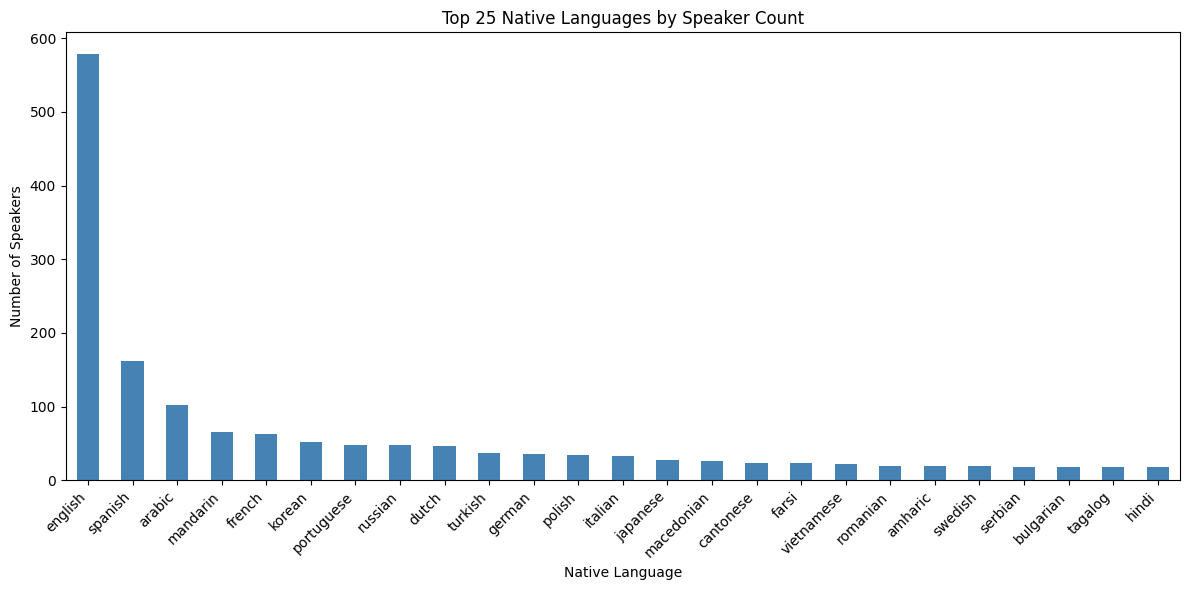

Total unique languages: 33


In [ ]:
# Plot the top 25 native languages on a bar chart
lang_counts = df['native_language'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
lang_counts.head(25).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 25 Native Languages by Speaker Count')
ax.set_xlabel('Native Language')
ax.set_ylabel('Number of Speakers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Total unique languages: {lang_counts.nunique()}")

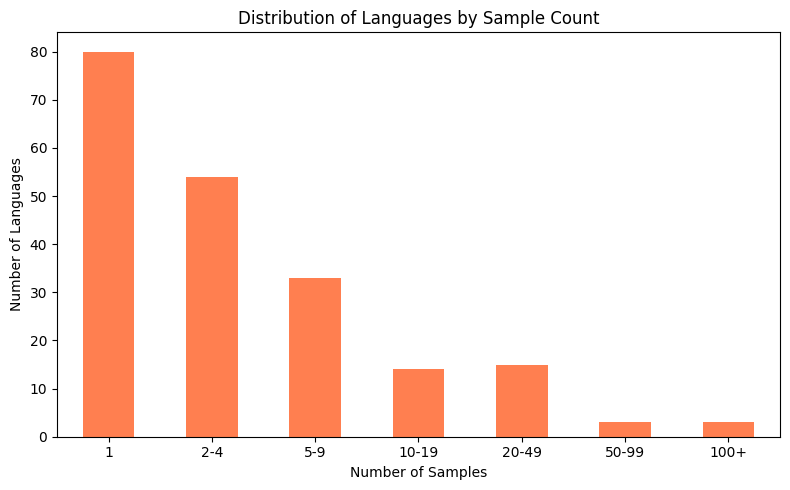

In [ ]:
# Long tail: how many languages have very few samples?
bins = [1, 2, 5, 10, 20, 50, 100, 600]
labels = ['1', '2-4', '5-9', '10-19', '20-49', '50-99', '100+']
lang_bins = pd.cut(lang_counts, bins=bins, labels=labels, right=False)

fig, ax = plt.subplots(figsize=(8, 5))
lang_bins.value_counts().sort_index().plot(kind='bar', ax=ax, color='coral')
ax.set_title('Distribution of Languages by Sample Count')
ax.set_xlabel('Number of Samples')
ax.set_ylabel('Number of Languages')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

115 languages have 2 or fewer speakers. This isn't ideal since it would be difficult to evaluate. As such, it would be tough for the model to detemine these languages given the lack of samples and so we should instead focus on languages with a larger number of recordings.

## Country Distribution
The second key column to explore further is the country feature, which showcases the speaker's country. As we can see from the code below, English-speaking countries dominate the dataset, with the United States being by far the most prominent country featured. After that there is a strong spread of countries to round out the rest of the top 25 by speaker count, as seen in the bar chart which is right-skewed.

In [ ]:
print(df['country'].value_counts())

country
usa             391
china            88
uk               67
india            58
canada           54
               ... 
bosnia            1
sicily            1
guatemala         1
turkmenistan      1
benin             1
Name: count, Length: 176, dtype: int64


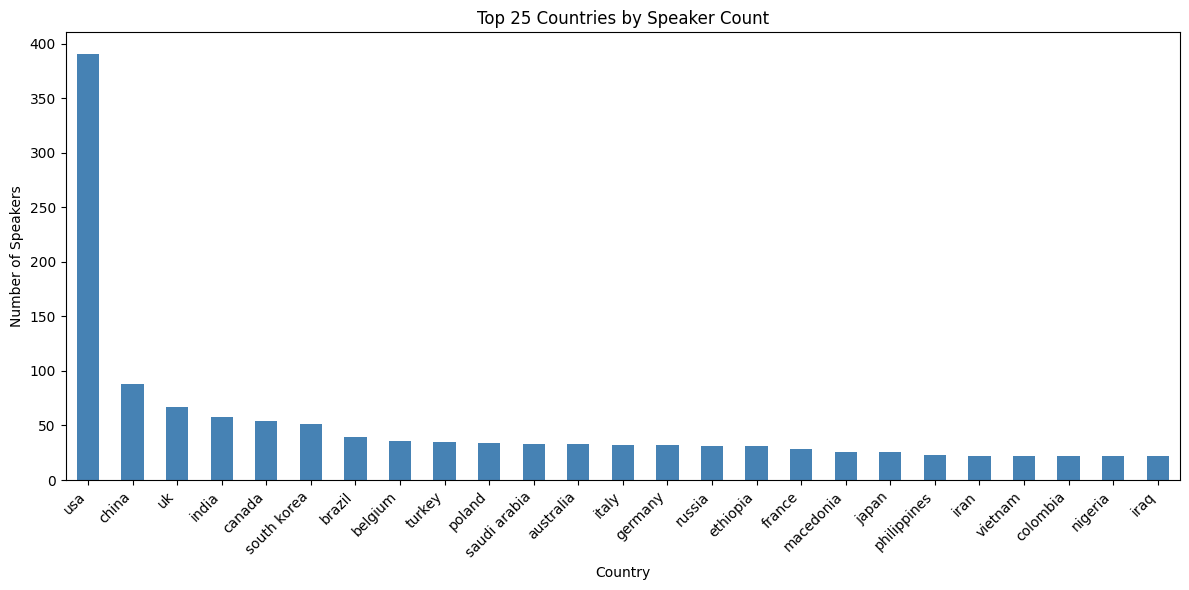

Total unique countries: 37


In [ ]:
country_counts = df['country'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
country_counts.head(25).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 25 Countries by Speaker Count')
ax.set_xlabel('Country')
ax.set_ylabel('Number of Speakers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Total unique countries: {country_counts.nunique()}")

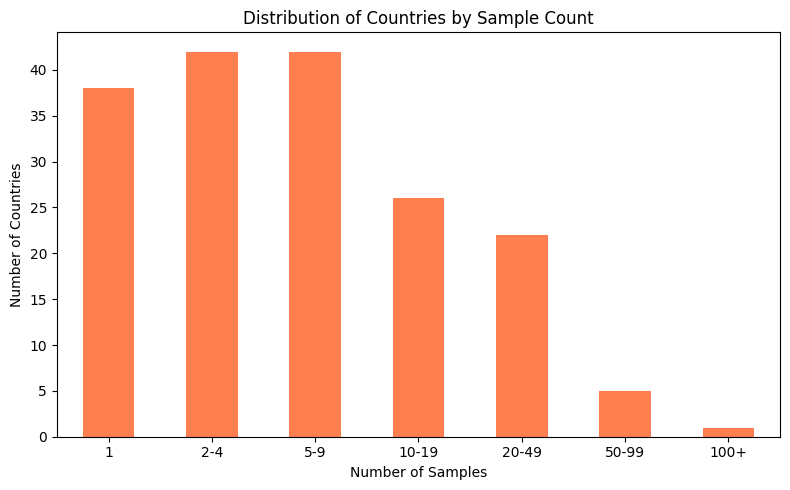

In [ ]:
bins = [1, 2, 5, 10, 20, 50, 100, 600]
labels = ['1', '2-4', '5-9', '10-19', '20-49', '50-99', '100+']
country_bins = pd.cut(country_counts, bins=bins, labels=labels, right=False)

fig, ax = plt.subplots(figsize=(8, 5))
country_bins.value_counts().sort_index().plot(kind='bar', ax=ax, color='coral')
ax.set_title('Distribution of Countries by Sample Count')
ax.set_xlabel('Number of Samples')
ax.set_ylabel('Number of Countries')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

As seen with the bar chart for the distribution of countries by sample count, we see a right skew again, although compared to the distribution of languages by sample count it is less prominent. The majority of countries have between 2-9 samples for the speakers.

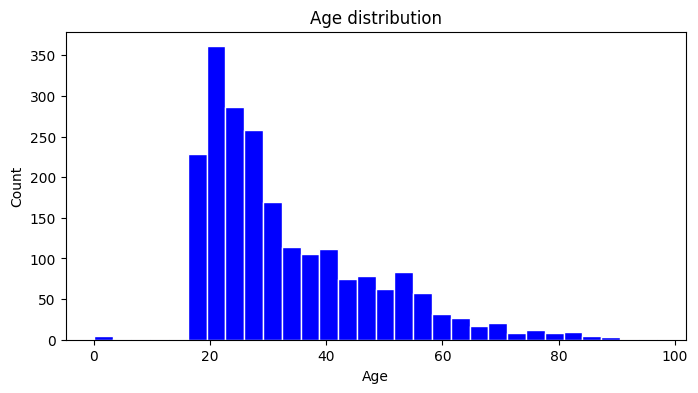

In [ ]:
# Distribution of age
plt.figure(figsize=(8, 4))
plt.hist(df['age'], bins=30, color='blue', edgecolor='white')
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

The histogram shows the distribution of speaker ages from all of 2,172 samples. The distribution is right-skewed, with the majority of speakers between the ages of 20 and ~35. It seems like the peak is at 20 - 23. There's very few speakers under the age of 17 or over 60 years old. That shows that this dataset primarily consists of young adults.

In [ ]:
# Sex distribution
print(df['sex'].value_counts())

sex
male      1103
female    1037
Name: count, dtype: int64


Found a spelling error in the dataset: famale. Let's fix it and clean it up!

In [ ]:
# Clean up time
df['sex'] = df['sex'].replace('famale', 'female')
print(df['sex'].value_counts())

sex
male      1103
female    1037
Name: count, dtype: int64


<Figure size 600x400 with 0 Axes>

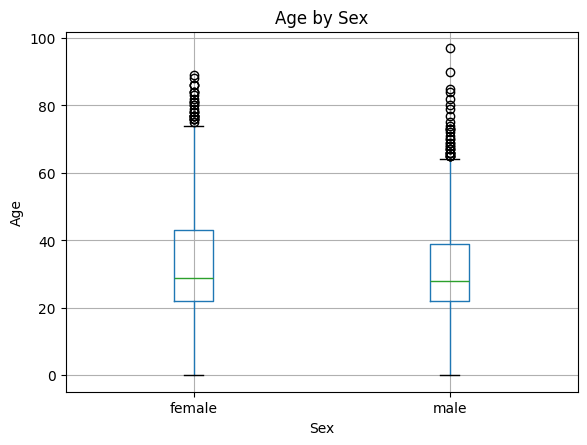

In [ ]:
# Age by sex
plt.figure(figsize=(6, 4))
df.boxplot(column='age', by='sex')
plt.title('Age by Sex')
plt.suptitle('')
plt.xlabel('Sex')
plt.ylabel('Age')
plt.show()

It seems that both sex speakers have a similar age distribution, with medians being around the age of 29. Both also seem to have a wide range of outliers extending from the age 70s and 80s. We shouldn't clean/remove these outliers as they are still part of the dataset and should be considered, what matters is the fact that we have audio recordings of them speaking in English for the model to work with in determining their accent.

## Class Threshold Analysis
We need a minimum number of samples per language to train a classifier. Too few and the model can't learn; too many of a cutoff and we lose language diversity.

In [ ]:
thresholds = [5, 10, 15, 20, 25, 30, 50]
rows = []
for t in thresholds:
    filtered = lang_counts[lang_counts >= t]
    rows.append({
        'min_samples': t,
        'num_classes': len(filtered),
        'total_samples': filtered.sum(),
        'smallest_class': filtered.min()
    })

threshold_df = pd.DataFrame(rows)
print(threshold_df.to_string(index=False))

 min_samples  num_classes  total_samples  smallest_class
           5           68           1918               5
          10           35           1687              10
          15           29           1622              15
          20           21           1487              20
          25           15           1359              26
          30           13           1306              33
          50            6           1023              52


In [ ]:
# Apply threshold: keep languages with >= 20 samples
MIN_SAMPLES = 20
keep_languages = lang_counts[lang_counts >= MIN_SAMPLES].index.tolist()
df_filtered = df[df['native_language'].isin(keep_languages)].copy()

print(f"Threshold: >= {MIN_SAMPLES} samples per language")
print(f"Classes kept: {len(keep_languages)}")
print(f"Samples kept: {len(df_filtered)} / {len(df)} ({len(df_filtered)/len(df)*100:.1f}%)")
print(f"\nLanguages included:")
print(df_filtered['native_language'].value_counts().to_string())

Threshold: >= 20 samples per language
Classes kept: 21
Samples kept: 1487 / 2140 (69.5%)

Languages included:
native_language
english       579
spanish       162
arabic        102
mandarin       65
french         63
korean         52
portuguese     48
russian        48
dutch          47
turkish        37
german         36
polish         34
italian        33
japanese       27
macedonian     26
farsi          23
cantonese      23
vietnamese     22
amharic        20
romanian       20
swedish        20


## Demographic Analysis
Understanding the demographic distribution of the filtered dataset.

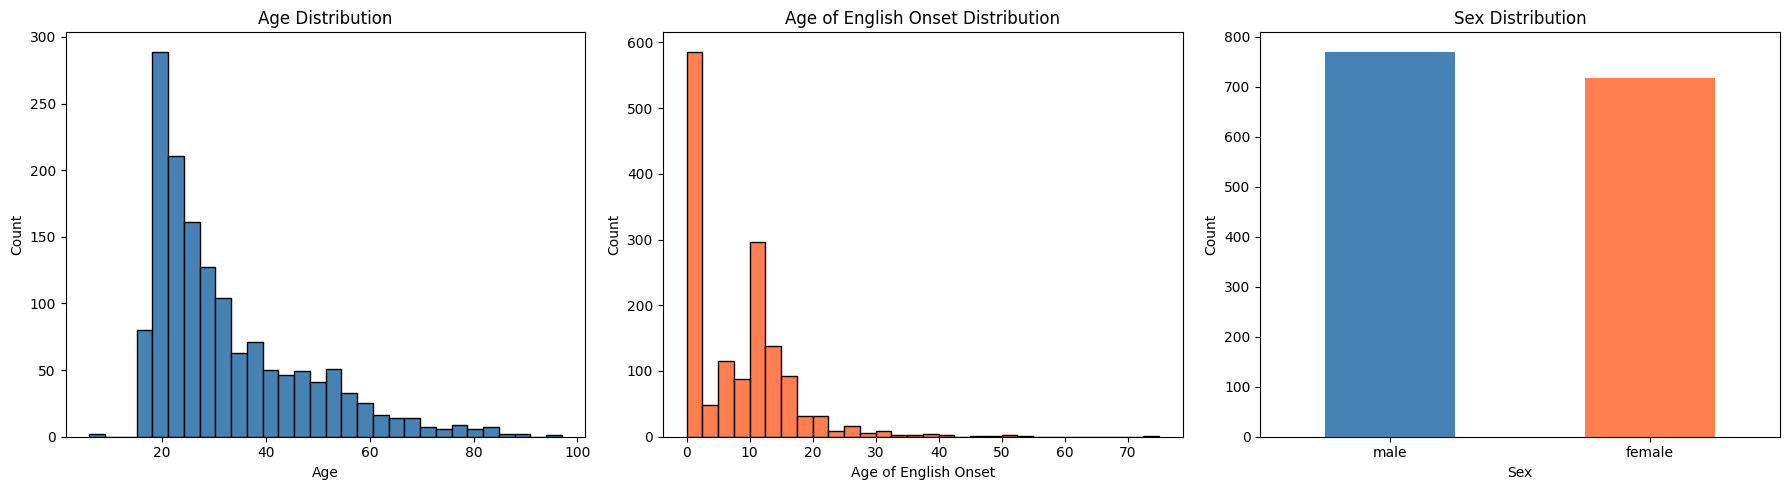

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age distribution
axes[0].hist(df_filtered['age'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Age of English onset distribution
axes[1].hist(df_filtered['age_onset'], bins=30, color='coral', edgecolor='black')
axes[1].set_title('Age of English Onset Distribution')
axes[1].set_xlabel('Age of English Onset')
axes[1].set_ylabel('Count')

# Sex distribution
df_filtered['sex'].value_counts().plot(kind='bar', ax=axes[2], color=['steelblue', 'coral'])
axes[2].set_title('Sex Distribution')
axes[2].set_xlabel('Sex')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

/tmp/ipykernel_699/1830459974.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='native_language', y='age_onset', ax=ax,


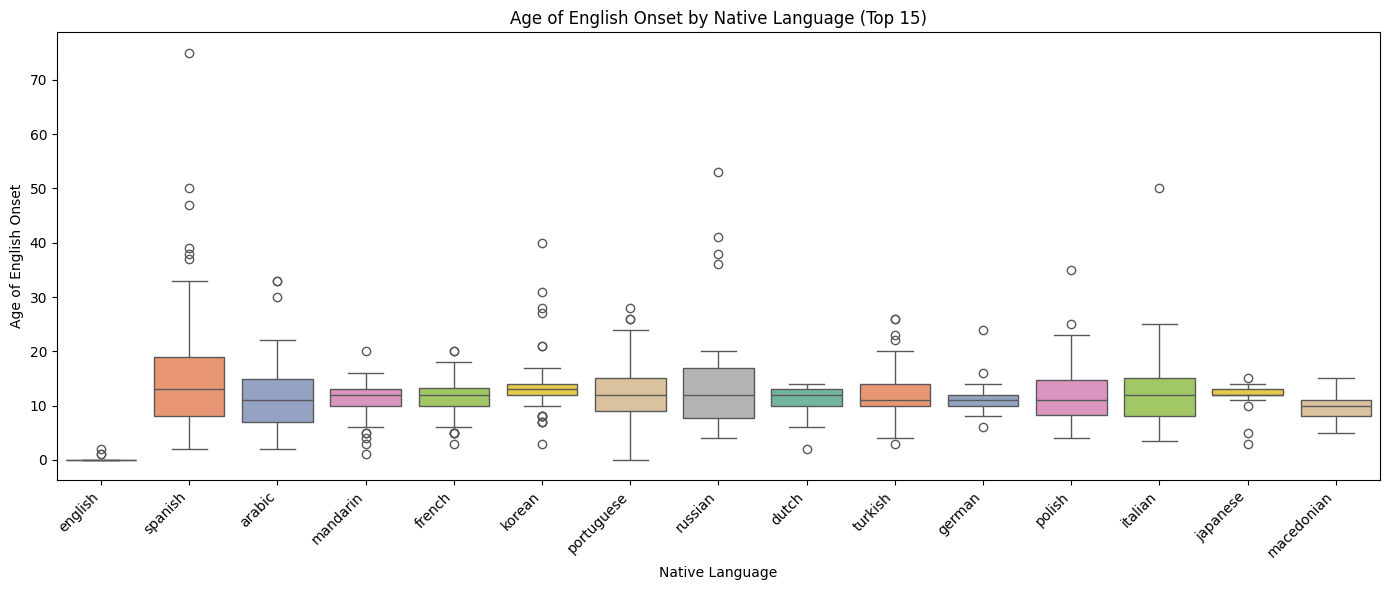

In [ ]:
# Age of onset by native language — shows how early speakers learned English
top_langs = df_filtered['native_language'].value_counts().head(15).index
plot_df = df_filtered[df_filtered['native_language'].isin(top_langs)]

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=plot_df, x='native_language', y='age_onset', ax=ax,
            order=top_langs, palette='Set2')
ax.set_title('Age of English Onset by Native Language (Top 15)')
ax.set_xlabel('Native Language')
ax.set_ylabel('Age of English Onset')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Cleaned Dataset Summary

In [ ]:
print("=" * 50)
print("CLEANED DATASET SUMMARY")
print("=" * 50)
print(f"Total samples:        {len(df_filtered)}")
print(f"Number of classes:    {df_filtered['native_language'].nunique()}")
print(f"Min samples/class:    {df_filtered['native_language'].value_counts().min()}")
print(f"Max samples/class:    {df_filtered['native_language'].value_counts().max()}")
print(f"Median samples/class: {df_filtered['native_language'].value_counts().median():.0f}")
print(f"Age range:            {df_filtered['age'].min():.0f} - {df_filtered['age'].max():.0f}")
print(f"Sex ratio (M/F):      {(df_filtered['sex']=='male').sum()} / {(df_filtered['sex']=='female').sum()}")
print(f"\nColumns: {list(df_filtered.columns)}")
print(f"\nReady for audio feature extraction (mel spectrograms).")

CLEANED DATASET SUMMARY
Total samples:        1487
Number of classes:    21
Min samples/class:    20
Max samples/class:    579
Median samples/class: 36
Age range:            6 - 97
Sex ratio (M/F):      770 / 717

Columns: ['age', 'age_onset', 'birthplace', 'filename', 'native_language', 'sex', 'speakerid', 'country', 'file_missing?']

Ready for audio feature extraction (mel spectrograms).


## Audio Feature Extraction
Load audio files and convert to mel spectrograms for the capsule network. Each recording is a speaker reading the same English passage, stored as `{filename}.mp3`.

In [ ]:
!pip install librosa

In [ ]:
import librosa
import librosa.display
import numpy as np

audio_dir = os.path.join(path, "recordings", "recordings")

# Build audio file path for each row
df_filtered['audio_file'] = df_filtered['filename'] + '.mp3'
df_filtered['audio_path'] = df_filtered['audio_file'].apply(lambda f: os.path.join(audio_dir, f))
df_filtered['audio_exists'] = df_filtered['audio_path'].apply(os.path.exists)

print(f"Audio files found: {df_filtered['audio_exists'].sum()} / {len(df_filtered)}")

Audio files found: 1487 / 1487


Sample: english1.mp3
Duration: 21.87s | Sample rate: 22050 Hz


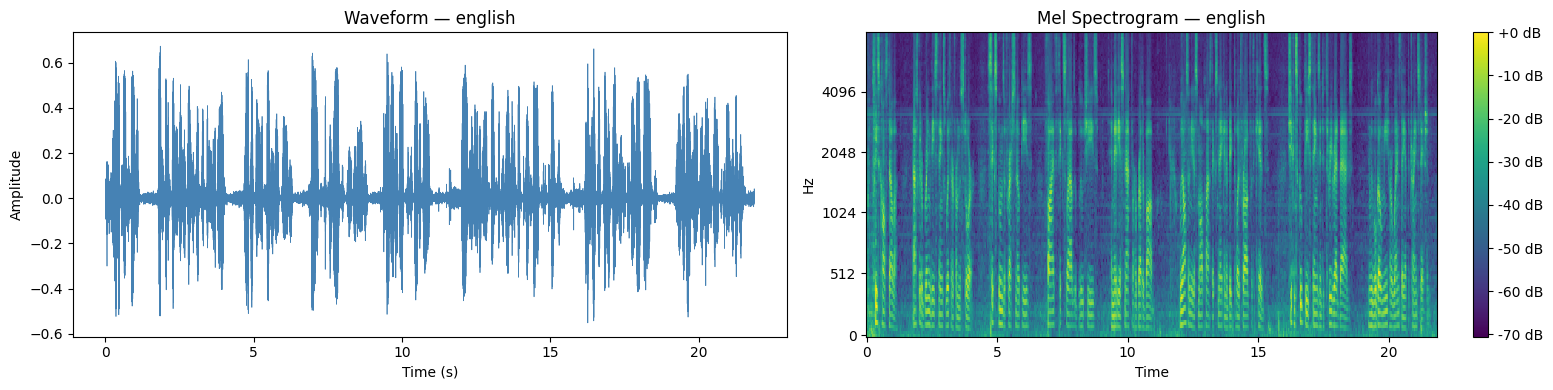

In [ ]:
# Load a sample audio file and visualize its mel spectrogram
sample_row = df_filtered[df_filtered['native_language'] == 'english'].iloc[0]
y, sr = librosa.load(sample_row['audio_path'], sr=22050)

print(f"Sample: {sample_row['audio_file']}")
print(f"Duration: {len(y)/sr:.2f}s | Sample rate: {sr} Hz")

# Generate mel spectrogram
mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Waveform
axes[0].plot(np.linspace(0, len(y)/sr, len(y)), y, color='steelblue', linewidth=0.5)
axes[0].set_title(f'Waveform — {sample_row["native_language"]}')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')

# Mel spectrogram
img = librosa.display.specshow(mel_spec_db, x_axis='time', y_axis='mel',
                                sr=sr, fmax=8000, ax=axes[1], cmap='viridis')
axes[1].set_title(f'Mel Spectrogram — {sample_row["native_language"]}')
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

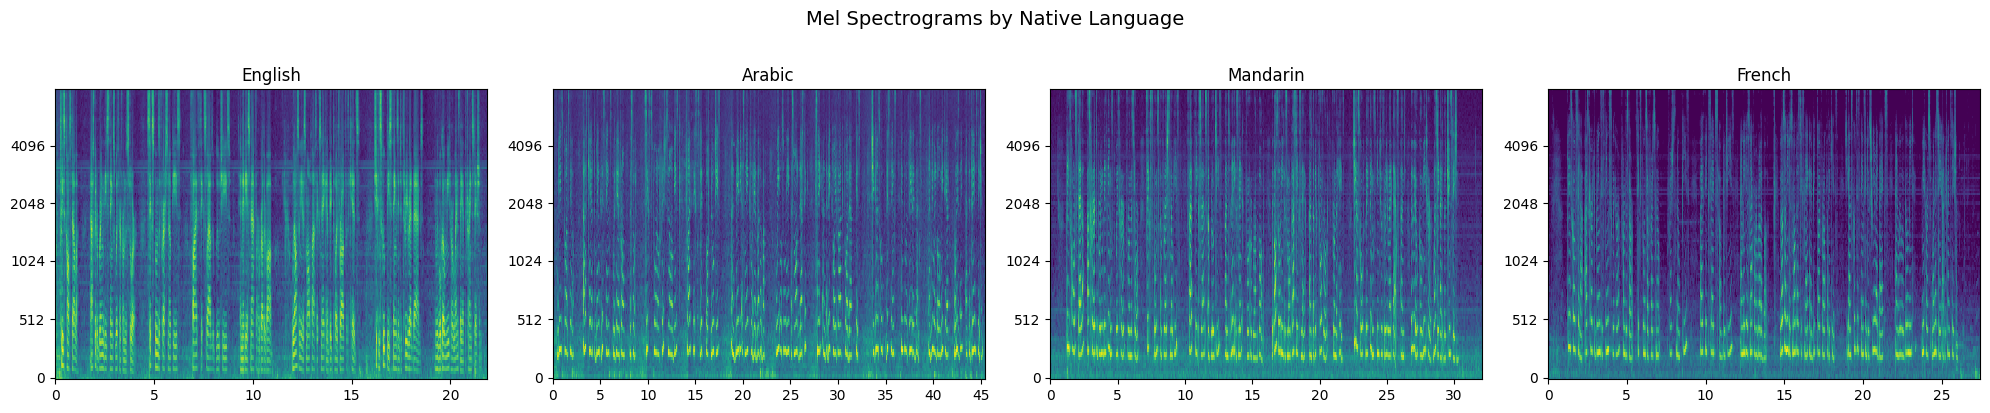

In [ ]:
# Compare mel spectrograms across 4 different accents
sample_langs = ['english', 'arabic', 'mandarin', 'french']
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, lang in zip(axes, sample_langs):
    row = df_filtered[df_filtered['native_language'] == lang].iloc[0]
    y, sr = librosa.load(row['audio_path'], sr=22050)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    librosa.display.specshow(mel_spec_db, x_axis='time', y_axis='mel',
                              sr=sr, fmax=8000, ax=ax, cmap='viridis')
    ax.set_title(lang.capitalize())
    ax.set_xlabel('')
    ax.set_ylabel('')

fig.suptitle('Mel Spectrograms by Native Language', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Duration stats (seconds):
count    1487.000000
mean       26.596479
std         7.317984
min        16.460544
25%        21.741270
50%        24.434830
75%        29.313719
max        85.119184
Name: duration, dtype: float64


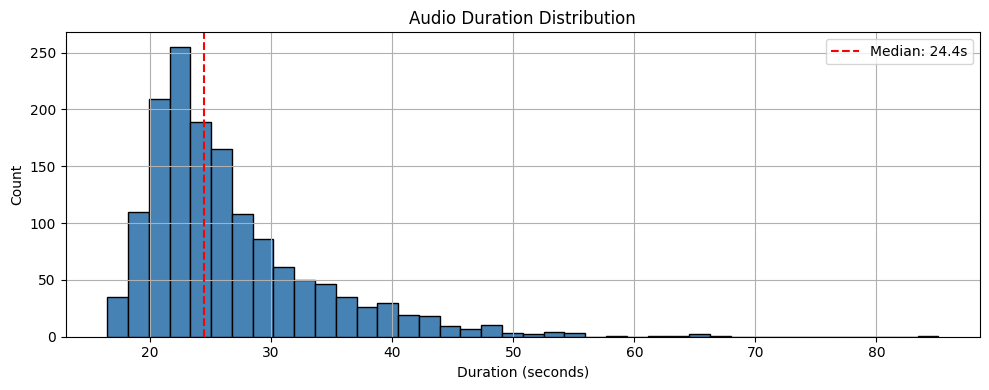

In [ ]:
# Check audio duration distribution across the filtered dataset
durations = []
for _, row in df_filtered.iterrows():
    try:
        y, sr = librosa.load(row['audio_path'], sr=22050)
        durations.append(len(y) / sr)
    except Exception:
        durations.append(None)

df_filtered['duration'] = durations

print(f"Duration stats (seconds):")
print(df_filtered['duration'].describe())

fig, ax = plt.subplots(figsize=(10, 4))
df_filtered['duration'].dropna().hist(bins=40, ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Audio Duration Distribution')
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Count')
ax.axvline(df_filtered['duration'].median(), color='red', linestyle='--', label=f"Median: {df_filtered['duration'].median():.1f}s")
ax.legend()
plt.tight_layout()
plt.show()

## Preprocessing
Convert all audio files to fixed-size mel spectrograms. Pad short clips and truncate long ones to a uniform duration.

In [ ]:
from sklearn.preprocessing import LabelEncoder

SR = 22050
N_MELS = 128
FMAX = 8000
# Use median duration as target length (adjust after seeing duration histogram)
TARGET_DURATION = df_filtered['duration'].median()
TARGET_SAMPLES = int(TARGET_DURATION * SR)
HOP_LENGTH = 512

print(f"Target duration: {TARGET_DURATION:.1f}s ({TARGET_SAMPLES} samples)")
print(f"Mel spectrogram shape per clip: ({N_MELS}, {TARGET_SAMPLES // HOP_LENGTH + 1})")

def audio_to_mel(file_path, sr=SR, n_mels=N_MELS, fmax=FMAX, target_samples=TARGET_SAMPLES):
    """Load audio and convert to a fixed-size mel spectrogram."""
    y, _ = librosa.load(file_path, sr=sr)

    # Pad or truncate to target length
    if len(y) < target_samples:
        y = np.pad(y, (0, target_samples - len(y)), mode='constant')
    else:
        y = y[:target_samples]

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, fmax=fmax, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db

Target duration: 24.4s (538788 samples)
Mel spectrogram shape per clip: (128, 1053)


In [ ]:
# Convert all audio files to mel spectrograms
spectrograms = []
labels = []
skipped = 0

for i, (_, row) in enumerate(df_filtered.iterrows()):
    try:
        mel = audio_to_mel(row['audio_path'])
        spectrograms.append(mel)
        labels.append(row['native_language'])
    except Exception as e:
        skipped += 1
        if skipped <= 3:
            print(f"Skipped {row['audio_file']}: {e}")

    if (i + 1) % 200 == 0:
        print(f"Processed {i + 1} / {len(df_filtered)}")

X = np.array(spectrograms)
print(f"\nDone. X shape: {X.shape}, Skipped: {skipped}")

# Encode labels
le = LabelEncoder()
y = le.fit_transform(labels)
print(f"y shape: {y.shape}, Classes: {le.classes_.tolist()}")

Processed 200 / 1487
Processed 400 / 1487
Processed 600 / 1487
Processed 800 / 1487
Processed 1000 / 1487
Processed 1200 / 1487
Processed 1400 / 1487

Done. X shape: (1487, 128, 1053), Skipped: 0
y shape: (1487,), Classes: ['amharic', 'arabic', 'cantonese', 'dutch', 'english', 'farsi', 'french', 'german', 'italian', 'japanese', 'korean', 'macedonian', 'mandarin', 'polish', 'portuguese', 'romanian', 'russian', 'spanish', 'swedish', 'turkish', 'vietnamese']


## Train / Validation / Test Split
Stratified by native language. 70% train, 15% validation, 15% test.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Add channel dimension: (N, 1, n_mels, time_steps)
X_tensor = torch.FloatTensor(X).unsqueeze(1)
y_tensor = torch.LongTensor(y)

print(f"X tensor: {X_tensor.shape}")
print(f"y tensor: {y_tensor.shape}")

# Stratified split: 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X_tensor, y_tensor, test_size=0.3, stratify=y_tensor, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"\nTrain: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")
print(f"Train class dist: {dict(zip(*np.unique(y_train.numpy(), return_counts=True)))}")

# Compute class weights for imbalanced data
class_weights = compute_class_weight('balanced', classes=np.unique(y_train.numpy()), y=y_train.numpy())
class_weights = torch.FloatTensor(class_weights)
print(f"\nClass weights (min={class_weights.min():.2f}, max={class_weights.max():.2f})")

# Create data loaders
BATCH_SIZE = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE)

X tensor: torch.Size([1487, 1, 128, 1053])
y tensor: torch.Size([1487])

Train: 1040 | Val: 223 | Test: 224
Train class dist: {np.int64(0): np.int64(14), np.int64(1): np.int64(71), np.int64(2): np.int64(16), np.int64(3): np.int64(33), np.int64(4): np.int64(405), np.int64(5): np.int64(16), np.int64(6): np.int64(44), np.int64(7): np.int64(25), np.int64(8): np.int64(23), np.int64(9): np.int64(19), np.int64(10): np.int64(36), np.int64(11): np.int64(18), np.int64(12): np.int64(46), np.int64(13): np.int64(24), np.int64(14): np.int64(34), np.int64(15): np.int64(14), np.int64(16): np.int64(34), np.int64(17): np.int64(113), np.int64(18): np.int64(14), np.int64(19): np.int64(26), np.int64(20): np.int64(15)}

Class weights (min=0.12, max=3.54)


## Capsule Network
A capsule network preserves spatial hierarchies in mel spectrograms that standard CNNs lose through pooling. Each capsule outputs a vector (not a scalar), where the vector's **length** represents the probability that a feature is present and its **orientation** encodes the feature's properties (e.g., formant relationships, timing patterns).

Architecture: Conv layers → Primary Capsules → Class Capsules (21 accent classes) with dynamic routing.

In [ ]:
def squash(x, dim=-1):
    """Squash activation: scales vectors so their length is between 0 and 1."""
    sq_norm = (x ** 2).sum(dim=dim, keepdim=True)
    scale = sq_norm / (1 + sq_norm)
    return scale * x / (sq_norm.sqrt() + 1e-8)


class MPSAdaptiveAvgPool2d(nn.Module):
    """AdaptiveAvgPool2d that works on MPS by falling back to CPU."""
    def __init__(self, output_size):
        super().__init__()
        self.output_size = output_size

    def forward(self, x):
        if x.device.type == 'mps':
            return F.adaptive_avg_pool2d(x.cpu(), self.output_size).to(x.device)
        return F.adaptive_avg_pool2d(x, self.output_size)


class PrimaryCapsules(nn.Module):
    def __init__(self, in_channels, num_capsules, capsule_dim, kernel_size, stride):
        super().__init__()
        self.capsule_dim = capsule_dim
        self.conv = nn.Conv2d(in_channels, num_capsules * capsule_dim,
                              kernel_size=kernel_size, stride=stride, padding=1)

    def forward(self, x):
        out = self.conv(x)  # (batch, num_caps * dim, H, W)
        batch, _, h, w = out.shape
        out = out.view(batch, -1, self.capsule_dim, h, w)  # (batch, num_caps, dim, H, W)
        out = out.permute(0, 1, 3, 4, 2).contiguous()  # (batch, num_caps, H, W, dim)
        out = out.view(batch, -1, self.capsule_dim)  # (batch, num_caps*H*W, dim)
        return squash(out)


class ClassCapsules(nn.Module):
    def __init__(self, num_capsules_in, capsule_dim_in, num_classes, class_capsule_dim, num_routing=3):
        super().__init__()
        self.num_classes = num_classes
        self.num_routing = num_routing
        self.W = nn.Parameter(
            torch.randn(1, num_capsules_in, num_classes, class_capsule_dim, capsule_dim_in) * 0.01
        )

    def forward(self, x):
        batch_size = x.size(0)
        # x: (batch, num_caps_in, dim_in)
        # Expand for matmul: (batch, num_caps_in, 1, dim_in, 1)
        x = x[:, :, None, :, None]
        # W: (1, num_caps_in, num_classes, dim_out, dim_in)
        u_hat = (self.W @ x).squeeze(-1)  # (batch, num_caps_in, num_classes, dim_out)

        # Dynamic routing
        b = torch.zeros(batch_size, u_hat.size(1), self.num_classes, device=u_hat.device)
        for i in range(self.num_routing):
            c = F.softmax(b, dim=2)
            s = (c.unsqueeze(-1) * u_hat).sum(dim=1)
            v = squash(s)
            if i < self.num_routing - 1:
                agreement = (u_hat * v.unsqueeze(1)).sum(dim=-1)
                b = b + agreement

        return v


class CapsuleNetwork(nn.Module):
    def __init__(self, input_shape, num_classes=21, primary_caps=8, primary_dim=8, class_dim=16):
        super().__init__()
        self.num_classes = num_classes

        # Conv backbone with aggressive downsampling
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            # Force spatial dims to a fixed small size
            MPSAdaptiveAvgPool2d((4, 8)),
        )

        # Primary capsules: 256 channels in, 4x8 spatial
        self.primary_caps = PrimaryCapsules(256, num_capsules=primary_caps,
                                             capsule_dim=primary_dim, kernel_size=3, stride=1)
        num_primary_total = primary_caps * 4 * 8  # 256 capsules

        # Class capsules
        self.class_caps = ClassCapsules(num_primary_total, primary_dim,
                                         num_classes, class_dim, num_routing=3)

    def forward(self, x):
        x = self.features(x)
        x = self.primary_caps(x)
        x = self.class_caps(x)
        probs = x.norm(dim=-1)
        return probs


# Build model
input_shape = X_train.shape[1:]
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Device: {device}")

model = CapsuleNetwork(input_shape, num_classes=len(le.classes_)).to(device)
class_weights = class_weights.to(device)

# Shape check
with torch.no_grad():
    sample = X_train[:2].to(device)
    out = model(sample)
    print(f"Input: {sample.shape} → Output: {out.shape}")

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Device: cuda
Input: torch.Size([2, 1, 128, 1053]) → Output: torch.Size([2, 21])
Total parameters: 1,207,232


## Training

In [ ]:
def margin_loss(probs, targets, num_classes, m_plus=0.9, m_minus=0.1, lam=0.5):
    """Capsule margin loss: penalizes incorrect capsule lengths."""
    one_hot = F.one_hot(targets, num_classes).float()
    loss_pos = one_hot * F.relu(m_plus - probs) ** 2
    loss_neg = lam * (1 - one_hot) * F.relu(probs - m_minus) ** 2
    return (loss_pos + loss_neg).sum(dim=-1).mean()


def train_epoch(model, loader, optimizer, num_classes, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        probs = model(X_batch)
        loss = margin_loss(probs, y_batch, num_classes)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct += (probs.argmax(dim=1) == y_batch).sum().item()
        total += len(y_batch)
    return total_loss / total, correct / total


def evaluate(model, loader, num_classes, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            probs = model(X_batch)
            loss = margin_loss(probs, y_batch, num_classes)
            total_loss += loss.item() * len(y_batch)
            correct += (probs.argmax(dim=1) == y_batch).sum().item()
            total += len(y_batch)
    return total_loss / total, correct / total

In [ ]:
NUM_EPOCHS = 50
LR = 1e-3
num_classes = len(le.classes_)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, num_classes, device)
    val_loss, val_acc = evaluate(model, val_loader, num_classes, device)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_capsule_model.pth')

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.3f}")

print(f"\nBest validation accuracy: {best_val_acc:.3f}")

Epoch   5/50 | Train Loss: 0.4369 Acc: 0.396 | Val Loss: 0.4668 Acc: 0.390
Epoch  10/50 | Train Loss: 0.4025 Acc: 0.447 | Val Loss: 0.4642 Acc: 0.417
Epoch  15/50 | Train Loss: 0.3521 Acc: 0.510 | Val Loss: 0.4983 Acc: 0.399
Epoch  20/50 | Train Loss: 0.2795 Acc: 0.633 | Val Loss: 0.4699 Acc: 0.426
Epoch  25/50 | Train Loss: 0.2334 Acc: 0.727 | Val Loss: 0.4733 Acc: 0.408
Epoch  30/50 | Train Loss: 0.2087 Acc: 0.773 | Val Loss: 0.4772 Acc: 0.408
Epoch  35/50 | Train Loss: 0.1970 Acc: 0.804 | Val Loss: 0.4835 Acc: 0.390
Epoch  40/50 | Train Loss: 0.1889 Acc: 0.817 | Val Loss: 0.4890 Acc: 0.395
Epoch  45/50 | Train Loss: 0.1823 Acc: 0.824 | Val Loss: 0.4854 Acc: 0.386
Epoch  50/50 | Train Loss: 0.1793 Acc: 0.834 | Val Loss: 0.4854 Acc: 0.390

Best validation accuracy: 0.444


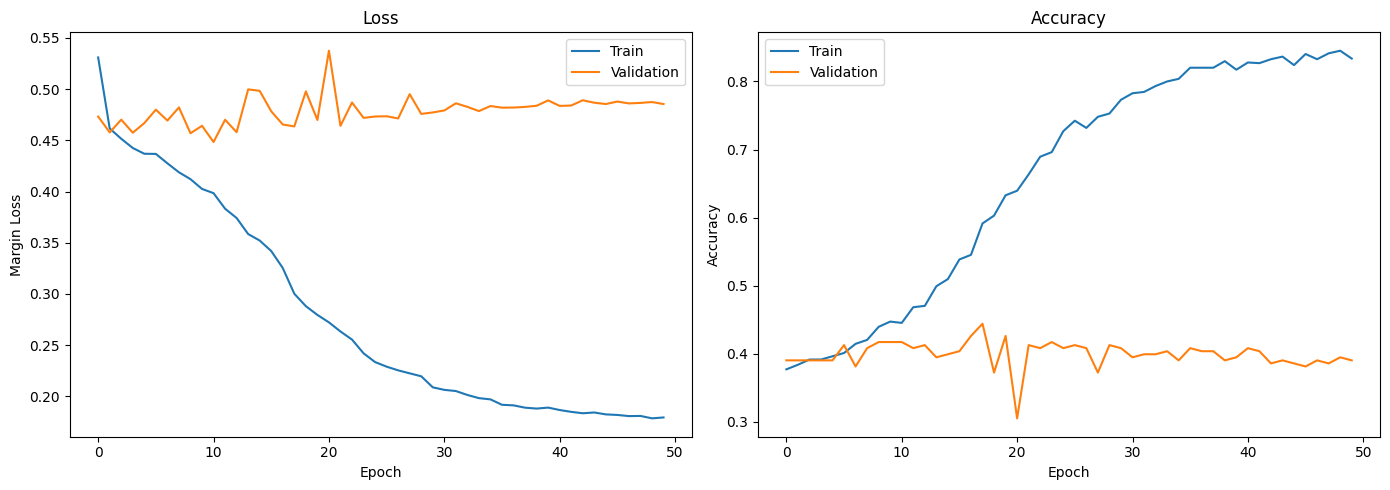

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train')
axes[0].plot(val_losses, label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Margin Loss')
axes[0].legend()

axes[1].plot(train_accs, label='Train')
axes[1].plot(val_accs, label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## Evaluation
Load the best model and evaluate on the held-out test set

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Load best model
model.load_state_dict(torch.load('best_capsule_model.pth', weights_only=True))
model.eval()

# Get predictions on test set
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        probs = model(X_batch.to(device))
        all_preds.extend(probs.argmax(dim=1).cpu().numpy())
        all_labels.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f"Test Accuracy: {test_acc:.3f}\n")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

Test Accuracy: 0.411

              precision    recall  f1-score   support

     amharic       0.00      0.00      0.00         3
      arabic       0.25      0.25      0.25        16
   cantonese       0.50      0.33      0.40         3
       dutch       0.20      0.29      0.24         7
     english       0.54      0.87      0.67        87
       farsi       0.00      0.00      0.00         3
      french       0.00      0.00      0.00        10
      german       0.00      0.00      0.00         6
     italian       0.00      0.00      0.00         5
    japanese       0.00      0.00      0.00         4
      korean       0.00      0.00      0.00         8
  macedonian       0.50      0.75      0.60         4
    mandarin       0.33      0.30      0.32        10
      polish       0.00      0.00      0.00         5
  portuguese       0.00      0.00      0.00         7
    romanian       0.00      0.00      0.00         3
     russian       0.00      0.00      0.00         7
     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


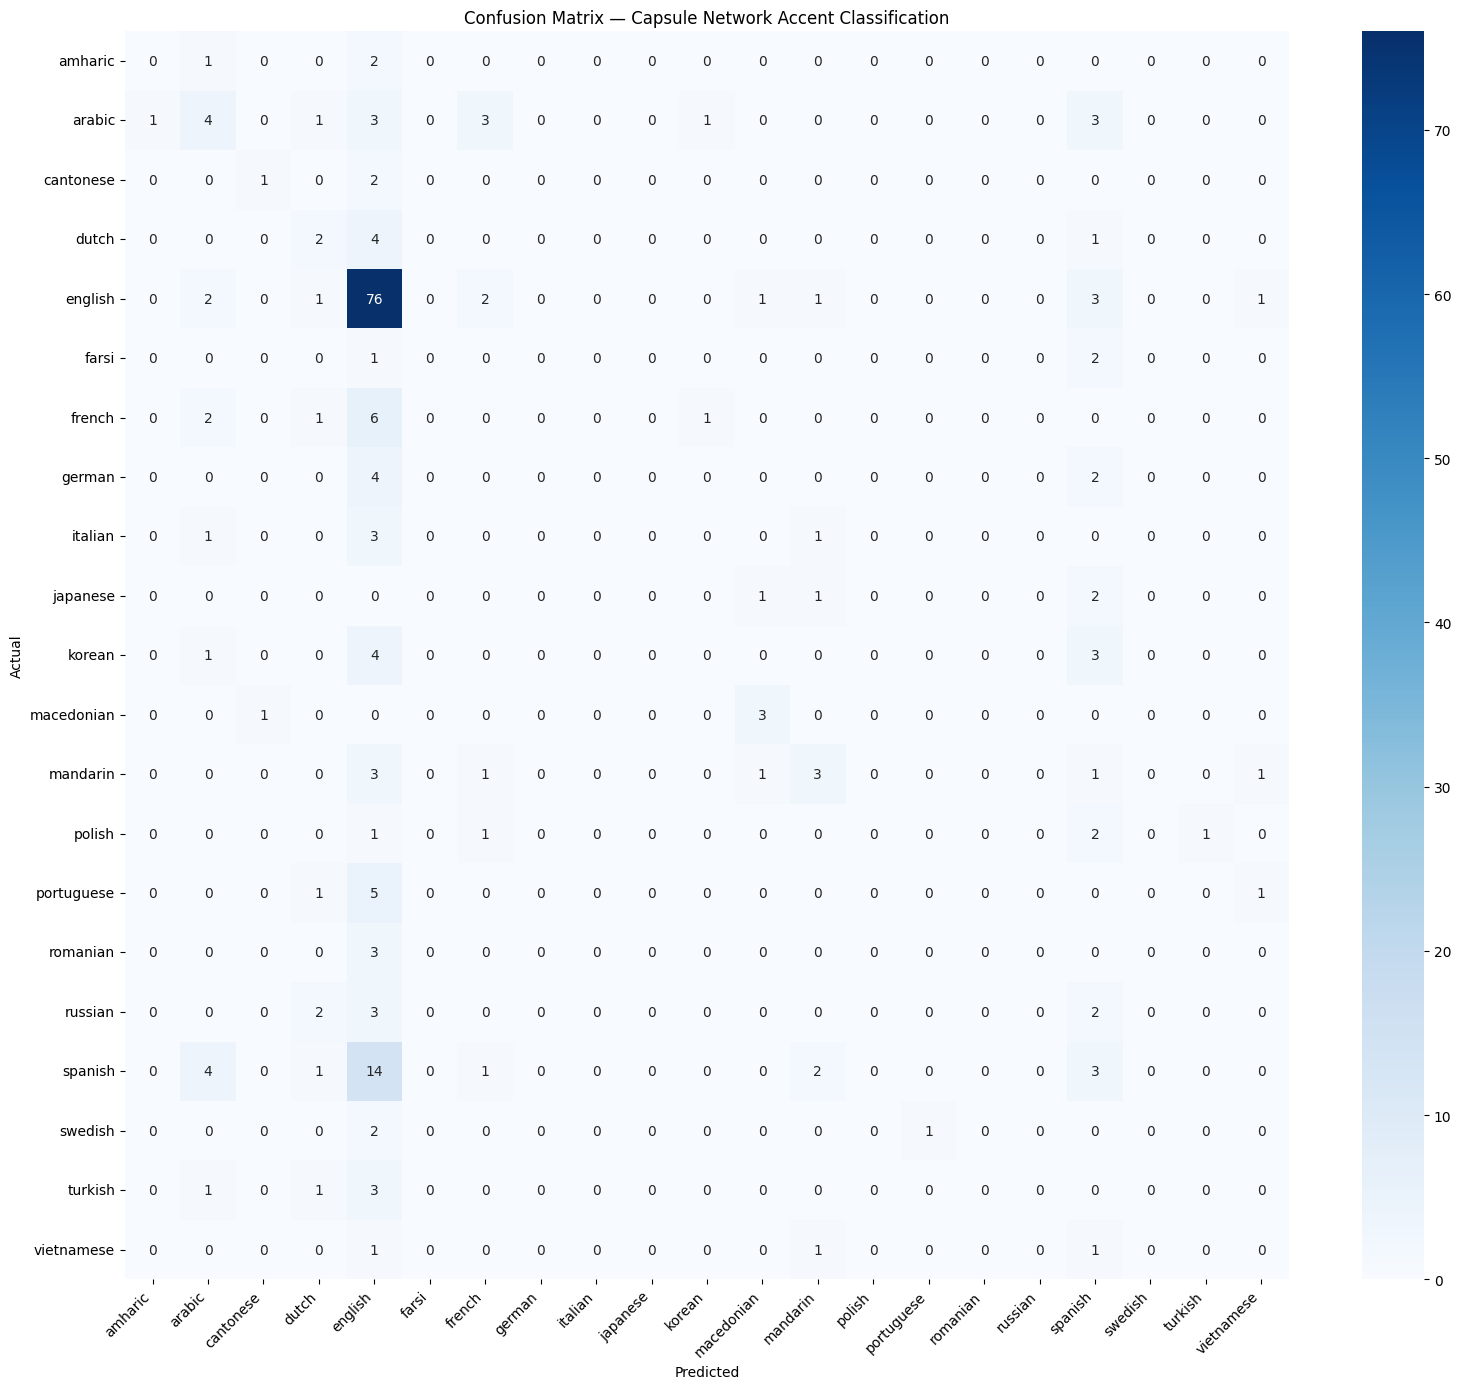

In [ ]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set_title('Confusion Matrix — Capsule Network Accent Classification')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

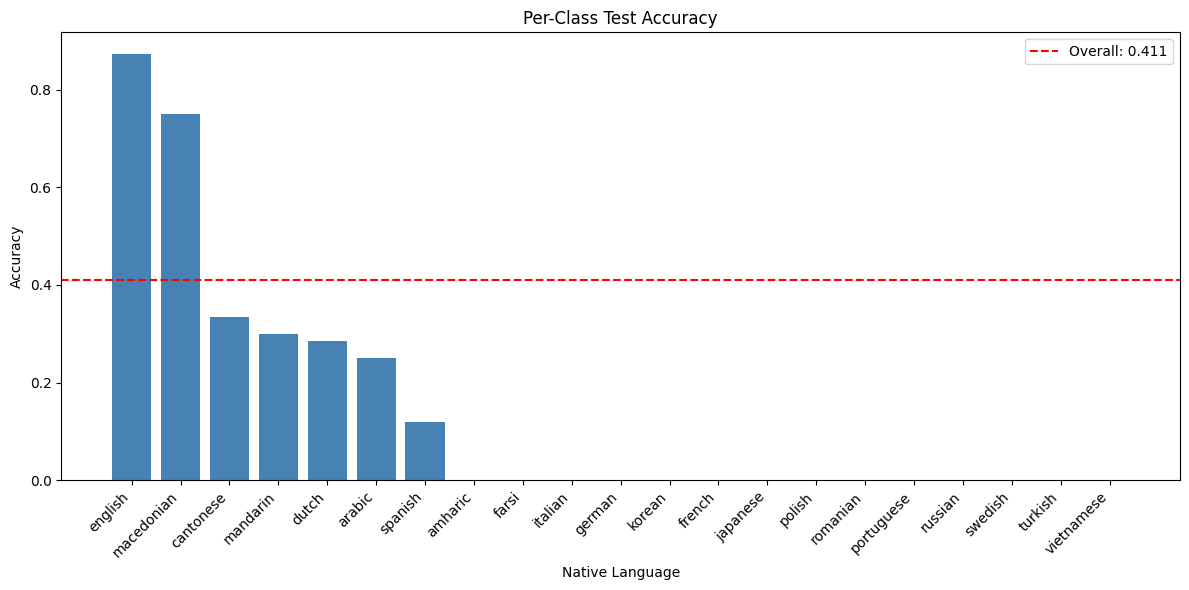

  language  accuracy  n_test
   english  0.873563      87
macedonian  0.750000       4
 cantonese  0.333333       3
  mandarin  0.300000      10
     dutch  0.285714       7
    arabic  0.250000      16
   spanish  0.120000      25
   amharic  0.000000       3
     farsi  0.000000       3
   italian  0.000000       5
    german  0.000000       6
    korean  0.000000       8
    french  0.000000      10
  japanese  0.000000       4
    polish  0.000000       5
  romanian  0.000000       3
portuguese  0.000000       7
   russian  0.000000       7
   swedish  0.000000       3
   turkish  0.000000       5
vietnamese  0.000000       3


In [ ]:
# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)
acc_df = pd.DataFrame({'language': le.classes_, 'accuracy': per_class_acc,
                        'n_test': cm.sum(axis=1)}).sort_values('accuracy', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(acc_df['language'], acc_df['accuracy'], color='steelblue')
ax.set_title('Per-Class Test Accuracy')
ax.set_xlabel('Native Language')
ax.set_ylabel('Accuracy')
ax.axhline(y=test_acc, color='red', linestyle='--', label=f'Overall: {test_acc:.3f}')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(acc_df.to_string(index=False))

## Dataset Quality
Overall, the Speech Accent Archive from Kaggle (originally from George Mason University) is a good quality dataset for our goal of speech accent classification. It originally has 2,172 audio samples. Every speaker in the dataset speaks the same passage in English, and while there are some limitations with the data in that a number of languages have an insufficient number of audio samples for the model to be trained on, there are still enough languages which have at least 20 samples for us to use.

We are able to filter these low sample count languages out and instead focus on languages which have sufficient data for us to use. As for the changes, transformations, and engineered features, we focused on cleaning the dataset, removing the unnamed columns and any data entries which did not have an audio file. In addition we fixed the "famale" typo in the sex column and then filtered the languages to only include those with at least 20 samples. We didn't specifically engineer any new features.